In [152]:
import os
import sys

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F
import math

notebook_dir = os.getcwd()
parent_dir = os.path.abspath(os.path.join(notebook_dir, ".."))
if parent_dir not in sys.path:
    sys.path.insert(0, parent_dir)
print(sys.path)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

%load_ext autoreload
%autoreload 2

['/Users/ben/Documents/work/research projects/local code/hdiva', '/Users/ben/.pyenv/versions/3.11.14/lib/python311.zip', '/Users/ben/.pyenv/versions/3.11.14/lib/python3.11', '/Users/ben/.pyenv/versions/3.11.14/lib/python3.11/lib-dynload', '', '/Users/ben/.pyenv/versions/3.11.14/envs/py311/lib/python3.11/site-packages']
The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# load and test infomax model (ring dataset)

using conditional generation

## data (ring)

In [ ]:
from a_datasets.ring.data import RingDataset

dataset = RingDataset(n_samples=1000, noise=0.1)
data = dataset.data

from torch.utils.data import DataLoader
dataloader = DataLoader(dataset, batch_size=512, shuffle=True)

[Text(0.5, 1.0, 'Ring Dataset'), Text(0.5, 0, 'X'), Text(0, 0.5, 'Y')]

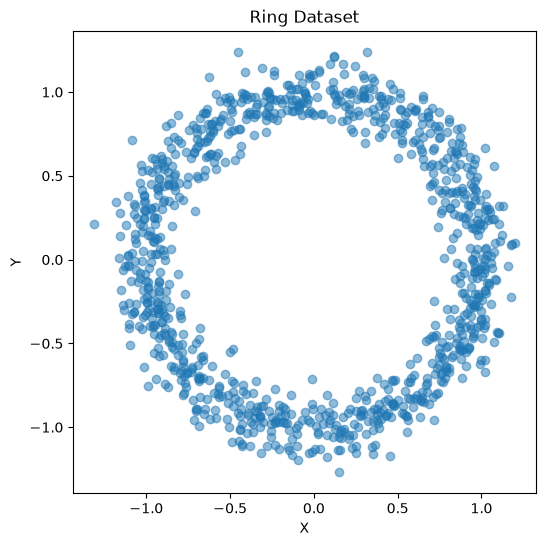

In [ ]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(data[:, 0], data[:, 1], alpha=0.5)
ax.set_aspect("equal")
ax.set(title="Ring Dataset", xlabel="X", ylabel="Y")

## conditional generation

In [761]:
from d_analysis.utils.sami_simple import init_sami_from_config
from b_models.sami.sami_inference_mlp import SAMI_Inference_MLP

dataset_name = "ring"  # ring or ellipse
model_num = 26

config, model, weights = init_sami_from_config(dataset_name, model_num)
model.load_state_dict(weights)
model.eval()
sami_inference = SAMI_Inference_MLP(sami=model, config=config).to(device)

print('beta value:', f'{config.beta_init:.2e}')
print('rate type:', f'{config.rate_type}')
print('latent dim:', f'{config.latent_dim}')

beta value: 1.20e-01
rate type: kl
latent dim: 2


number of samples: 100


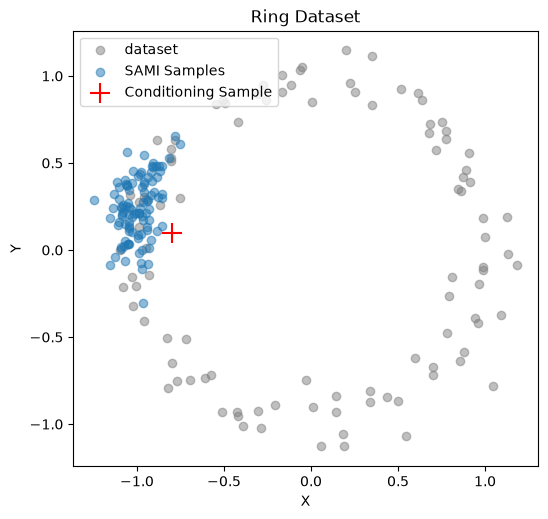

In [28]:
sami_inference.eval()

conditioning_sample = torch.tensor([[-0.8, 0.1]]).to(device)

sami_inference.conditional_sample(
    N = 100,
    target_x_input = conditioning_sample,
)

samples = sami_inference.x0_estimates[0].cpu().numpy()
print('number of samples:', samples.shape[0])
conditioning_sample_np = conditioning_sample.cpu().numpy()

#plot
fig, ax = plt.subplots(figsize=(6, 6))

ax.scatter(data[:, 0], data[:, 1], alpha=0.5, label="dataset", color='gray')
ax.scatter(samples[:, 0], samples[:, 1], alpha=0.5, label="SAMI Samples")
ax.scatter(conditioning_sample_np[:, 0], conditioning_sample_np[:, 1], marker="+", alpha=1., s=200, color='red', label="Conditioning Sample")

ax.set(title="Ring Dataset", xlabel="X", ylabel="Y")
ax.set_aspect("equal")
# ax.set(xlim=(-1.5, 1.5), ylim=(-1.5, 1.5))
ax.legend(loc="upper left")

# samples

## see what the latents look like

(200, 2)
torch.Size([200, 2])
torch.Size([200, 2])


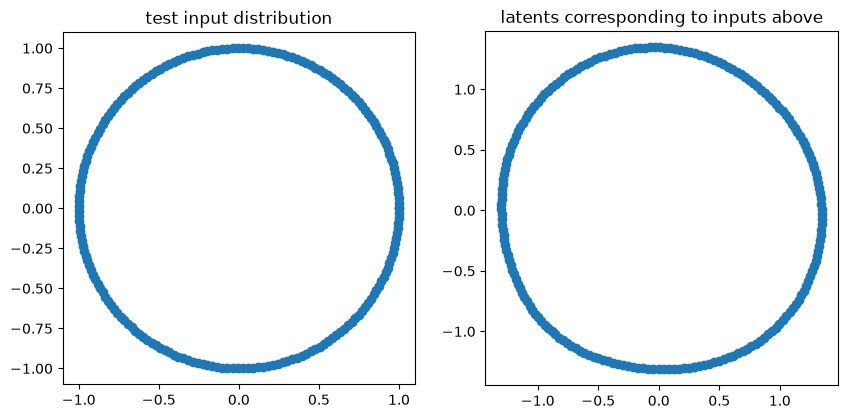

In [15]:
n_input_samples = 200
angles = np.linspace(0, 2 * np.pi, n_input_samples)
noiseless_data = np.stack((np.cos(angles), np.sin(angles)), axis=1)
print(noiseless_data.shape)

# now put this data into the encoder and see what the latent means are
# means = model.infnet(noiseless_data, t=torch.zeros(noiseless_data.shape[0],))[0]
x = torch.as_tensor(noiseless_data, dtype=torch.float32, device=next(model.infnet.parameters()).device)
print(x.shape)

model.eval()
with torch.no_grad():
    means, logvars = sami_inference.encode(model.infnet, x, t=None)
print(means.shape)


#### plot
fig, ax = plt.subplots(1, 2, figsize=(10,6))
ax[0].scatter(*noiseless_data.T)
ax[0].set(title='test input distribution')
ax[0].set_aspect("equal")

ax[1].scatter(*means.T)
ax[1].set(title="latents corresponding to inputs above")
ax[1].set_aspect("equal")

## measure rate distortion

In [32]:
# input is randomly sampled from dataset
from a_datasets.ring.data import RingDataset
from torch.utils.data import DataLoader
from d_analysis.utils.sami_simple import get_rd

dataset_rd = RingDataset(n_samples=100, noise=0.1)
dataloader_rd = DataLoader(dataset_rd, batch_size=20, shuffle=True)

d, r = get_rd(dataloader_rd, sami_inference, config, num_iters=1000)
print('distortion:', d)
print('rate:', r)

distortion: 0.15437678406778724
rate: 3.7954511919004843


# load and test infomax model (ellipse dataset)

## dataset (ellipse)

In [281]:
from a_datasets.ellipse.data import EllipseDataset

dataset = EllipseDataset(n_samples=1000, noise=0.0)
data = dataset.data

from torch.utils.data import DataLoader
dataloader = DataLoader(dataset, batch_size=512, shuffle=True)

[Text(0.5, 1.0, 'Ring Dataset'), Text(0.5, 0, 'X'), Text(0, 0.5, 'Y')]

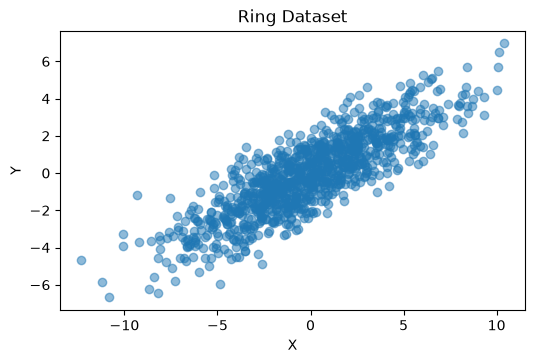

In [282]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(data[:, 0], data[:, 1], alpha=0.5)
ax.set_aspect("equal")
ax.set(title="Ring Dataset", xlabel="X", ylabel="Y")

## conditional generation

In [283]:
from d_analysis.utils.sami_simple import init_sami_from_config
from b_models.sami.sami_inference_mlp import SAMI_Inference_MLP

dataset_name = "ellipse"  # ring or ellipse
model_num = 1

config, model, weights = init_sami_from_config(dataset_name, model_num)
model.load_state_dict(weights)
model.eval()
sami_inference = SAMI_Inference_MLP(sami=model, config=config).to(device)

print('beta value:', f'{config.beta_init:.2e}')
print('rate type:', f'{config.rate_type}')

beta value: 1.00e-04
rate type: kl


## see what the latents look like

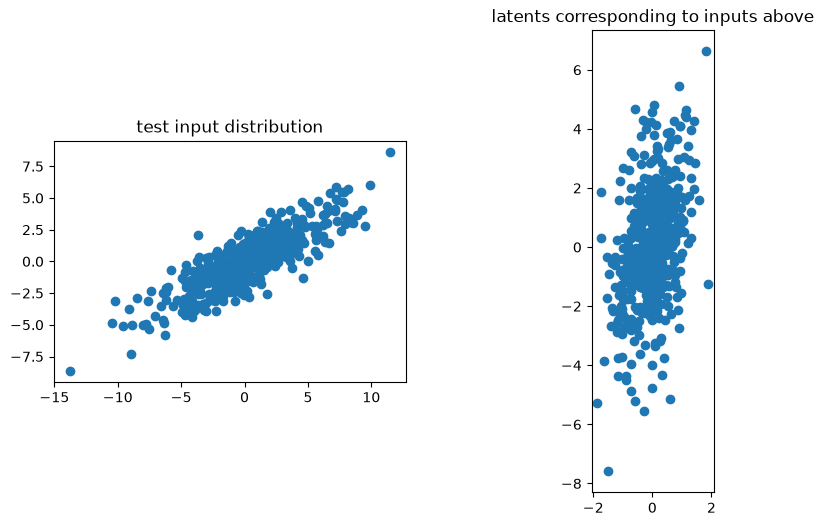

In [284]:
n_input_samples = 500
dataset = EllipseDataset(n_samples=n_input_samples, noise=0.0)
data = dataset.data

# now put this data into the encoder and see what the latent means are
# means = model.infnet(noiseless_data, t=torch.zeros(noiseless_data.shape[0],))[0]
x = torch.as_tensor(data, dtype=torch.float32, device=next(model.infnet.parameters()).device)

model.eval()
with torch.no_grad():
    means, logvars = sami_inference.encode(model.infnet, x, t=None)


#### plot
fig, ax = plt.subplots(1, 2, figsize=(10,6))
ax[0].scatter(*data.T)
ax[0].set(title='test input distribution')
ax[0].set_aspect("equal")

ax[1].scatter(*means.T)
ax[1].set(title="latents corresponding to inputs above")
ax[1].set_aspect("equal")

## measure rate distortion

In [157]:
# input is randomly sampled from dataset
from a_datasets.ring.data import RingDataset
from a_datasets.ellipse.data import EllipseDataset
from torch.utils.data import DataLoader
from d_analysis.utils.sami_simple import get_rd

# dataset = RingDataset(n_samples=100, noise=0.1)
dataset_rd = EllipseDataset(n_samples=100, noise=0.1)
dataloader_rd = DataLoader(dataset_rd, batch_size=20, shuffle=True)

d, r = get_rd(dataloader_rd, sami_inference, config, num_iters=1000)
print('distortion:', d)
print('rate:', r)

distortion: 0.5064146706009575
rate: 0.10606881211050787


# compare R-D plot (infomax vs elbo) over betas

Suppose we have a model trained at a set value of beta and a test input. 
To get a single point on the r-d plot, we noise the point up to a certain value of gamma, then denoise the noisy datum, conditioned on the latents of the clean datum. 

We measure the rate and distortion of this model (at fixed beta and gamma) by measuring the norm of the guidance score and the MSE between the clean and denoised data. 

We want to average over different test inputs and instances of noise, so we take the average over multiple test points, all noised to the same level of gamma. 

To get a point on the R-D plot, we need to do this for many different values of noise (gamma) and sum the results. 

To get the whole R-D curve, we repeat the above procedure for many different models, trained at different betas.  

In [285]:
dataset_name = "ellipse"  # ellipse or ring

## infomax (rate type=norm)

In [657]:
from utils.config_search import ConfigQuery, find_models, use_dataset
from utils.config_diff import diff_configs, print_diff

search_criteria = ConfigQuery(
    dataset_name = dataset_name,
    rate_type = "norm",
    latent_dim = 2,
)

use_dataset(dataset_name)
nums = find_models(search_criteria)

# nums.remove(1)
# nums.remove(7)
# nums.remove(11)

if len(nums) == 1:
    print(nums)
else:
    print_diff(nums)

model_nums = nums
# model_nums = [29, 11, 12, 13, 14, 15, 30]

1 differing fields across models [14, 15, 16, 17, 18, 19, 20, 21, 23, 24, 25, 26]

field      v014  v015  v016  v017  v018  v019   v020   v021    v023   v024  v025  v026
---------  ----  ----  ----  ----  ----  -----  -----  ------  -----  ----  ----  ----
beta_init  1.0   0.5   0.1   0.05  0.01  0.005  0.001  0.0005  5e-05  2.0   1.5   1.2


In [658]:
# now repeat this for many betas 
from a_datasets.ring.data import RingDataset
from a_datasets.ellipse.data import EllipseDataset
from torch.utils.data import DataLoader
from d_analysis.utils.sami_simple import get_rd

if dataset_name == "ring":
    dataset = RingDataset(n_samples=100, noise=0.1)
elif dataset_name == "ellipse":
    dataset = EllipseDataset(n_samples=100, noise=0.1)
dataloader = DataLoader(dataset, batch_size=100, shuffle=True)

rd_points = []

for model_num in model_nums:
    config, model, weights = init_sami_from_config(dataset_name=dataset_name, model_num=model_num)
    print('model number:', model_num)
    print(f'beta: {config.beta_init:1e}')
    assert config.rate_type == 'norm'
    model.load_state_dict(weights)
    model.eval()
    sami_inference = SAMI_Inference_MLP(sami=model, config=config).to(device)

    d, r = get_rd(dataloader, sami_inference, config, num_iters=4000)
    rd_points.append({'beta': config.beta_init, 'rate': r, 'distortion': d})

rd_points

model number: 14
beta: 1.000000e+00
model number: 15
beta: 5.000000e-01
model number: 16
beta: 1.000000e-01
model number: 17
beta: 5.000000e-02
model number: 18
beta: 1.000000e-02
model number: 19
beta: 5.000000e-03
model number: 20
beta: 1.000000e-03
model number: 21
beta: 5.000000e-04
model number: 23
beta: 5.000000e-05
model number: 24
beta: 2.000000e+00
model number: 25
beta: 1.500000e+00
model number: 26
beta: 1.200000e+00


[{'beta': 1.0, 'rate': 0.11772005664021708, 'distortion': 0.48903919965239767},
 {'beta': 0.5, 'rate': 0.31490998151828536, 'distortion': 0.39646523388697824},
 {'beta': 0.1, 'rate': 1.5384117463815492, 'distortion': 0.20040895079282928},
 {'beta': 0.05, 'rate': 2.6658359462628143, 'distortion': 0.15713557079427118},
 {'beta': 0.01, 'rate': 7.482318422039738, 'distortion': 0.07398083359298471},
 {'beta': 0.005,
  'rate': 10.029707282367163,
  'distortion': 0.05475755448105338},
 {'beta': 0.001, 'rate': 24.02913084047707, 'distortion': 0.02339993803370453},
 {'beta': 0.0005,
  'rate': 32.37307680465281,
  'distortion': 0.01761711441303487},
 {'beta': 5e-05,
  'rate': 63.46093182882294,
  'distortion': 0.008199272355344874},
 {'beta': 2.0, 'rate': 1.027105178451393e-05, 'distortion': 0.651559283915587},
 {'beta': 1.5, 'rate': 0.04712073331073043, 'distortion': 0.553413069202601},
 {'beta': 1.2, 'rate': 0.08458071041537915, 'distortion': 0.5062141934617612}]

In [659]:
# save rd_points_kl
mode = 'save'

import json
save_loc = f"{parent_dir}/c_training/local_weights/{dataset_name}"
if mode == 'save':
    with open(f"{save_loc}/rd_points_norm.json", "w") as f:
        json.dump(rd_points, f, indent=2)
elif mode == 'load':
    with open(f"{save_loc}/rd_points_norm.json") as f:
        rd_points = json.load(f)

In [461]:
rd_points_2d_latents_saved = [{'beta': 0.1, 'rate': 0.7530582937824074, 'distortion': 0.1481799428953673},
 {'beta': 0.01, 'rate': 4.398003532371251, 'distortion': 0.06946546124109591},
 {'beta': 0.001,
  'rate': 18.25297308541322,
  'distortion': 0.021728250912958175},
 {'beta': 0.0001,
  'rate': 54.50349365925975,
  'distortion': 0.01014918991815648},
 {'beta': 1e-05,
  'rate': 57.871776158479044,
  'distortion': 0.005362078794067202},
 {'beta': 0.5,
  'rate': 1.7387973454788154e-05,
  'distortion': 0.34533490771701325},
 {'beta': 0.2, 'rate': 0.4086610189285129, 'distortion': 0.18466993952129268},
 {'beta': 0.3, 'rate': 0.23246037111245096, 'distortion': 0.23997746800456662},
 {'beta': 0.05, 'rate': 1.383522566376836, 'distortion': 0.12711247328604805},
 {'beta': 0.005,
  'rate': 6.829189266108442,
  'distortion': 0.055040267919161126},
 {'beta': 0.0005,
  'rate': 31.301974531880813,
  'distortion': 0.016386718542620655}]

collapse betas: [2.0]


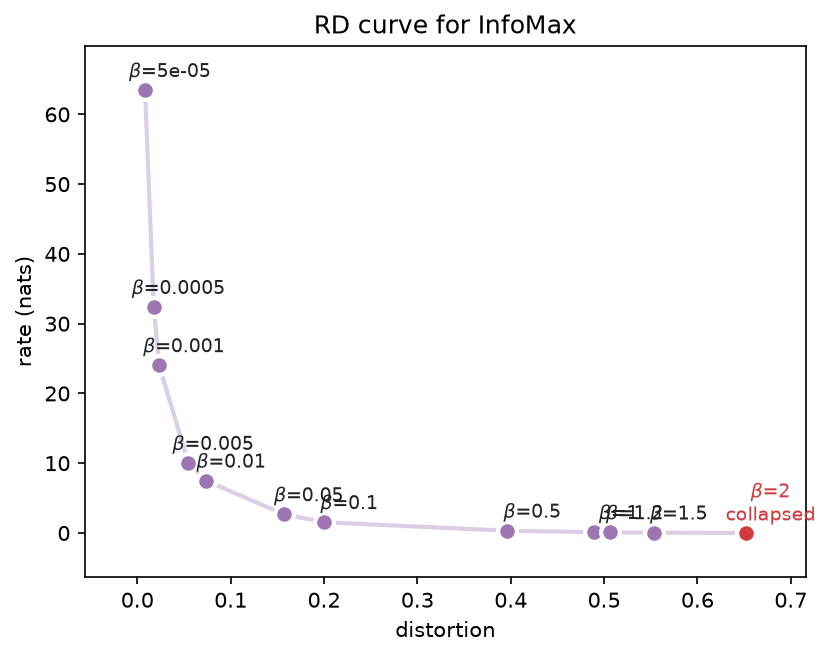

In [660]:
ACCENT, INK, MUTED = "#9D75B3", "#1f2328", "#8b9199"
COLLAPSE = "#d03b3b"
COLLAPSE_RATE = 1e-2   # nats; below this the latent carries no information

# beta_to_remove = [0.0001]
beta_to_remove = []
rd_points = [item for item in rd_points if item["beta"] not in beta_to_remove]

# pts = sorted(rd_points_kl, key=lambda p: p["beta"])
pts = sorted(rd_points, key=lambda p: p["beta"])

# pts = sorted(rd_points, key=lambda p: p["beta"])


D = [p["distortion"] for p in pts]
R = [p["rate"] for p in pts]
B = [p["beta"] for p in pts]
collapsed = [p["rate"] < COLLAPSE_RATE for p in pts]

# Pareto frontier: no other point has both lower rate and lower distortion.
# Collapsed runs aren't operating points, so they're excluded from the frontier.
on_front = [
    (not c) and not any(
        q["rate"] <= p["rate"] and q["distortion"] <= p["distortion"] and q is not p
        for q in pts
    )
    for p, c in zip(pts, collapsed)
]

fig, ax = plt.subplots(figsize=(6.2, 4.6), dpi=150)

# sweep trajectory, in beta order
ax.plot(D, R, "-", color=ACCENT, lw=2, alpha=0.35, zorder=1)

for d, r, c, front in zip(D, R, collapsed, on_front):
    if c:                                    # posterior collapse
        ax.plot(d, r, "o", ms=9, color=COLLAPSE, mec="white", mew=2, zorder=5)
    elif front:                              # on the frontier
        ax.plot(d, r, "o", ms=9, color=ACCENT, mec="white", mew=2, zorder=3)
    else:                                    # dominated by another beta
        ax.plot(d, r, "o", ms=9, color="white", mec=ACCENT, mew=2, zorder=4)

for d, r, b, c, front in zip(D, R, B, collapsed, on_front):
    label = rf"$\beta$={b:g}" + ("\ncollapsed" if c else "")
    ax.annotate(label, (d, r), textcoords="offset points",
                xytext=(12, 6), ha="center", fontsize=9,
                color=COLLAPSE if c else (INK if front else MUTED))

ax.set(ylabel='rate (nats)', xlabel='distortion')

R_range = max(R) - min(R)
ax.set(ylim=(min(R)-R_range*0.1, max(R)+R_range*0.1))
D_range = max(D) - min(D)
ax.set(xlim=(min(D)-D_range*0.1, max(D)+D_range*0.1))

ax.set(title="RD curve for InfoMax")


# save the betas that are collapsed
collapse_betas = [b for b, c in zip(B, collapsed) if c]
print('collapse betas:', collapse_betas)

## elbo (rate type=kl)

In [661]:
from utils.config_search import ConfigQuery, find_models, use_dataset
from utils.config_diff import diff_configs, print_diff

search_criteria = ConfigQuery(
    rate_type = "kl",
    latent_dim = 2,
    # freeze_denoiser = False,
    # beta_init = 1e-2,
)

use_dataset(dataset_name)
nums = find_models(search_criteria)
# nums.remove(15)  # 0.001
# nums.remove(16)  # 0.0001
# nums.remove(17)  # 1.0
# nums.remove(22)  # 0.002

if len(nums) == 1:
    print(nums)
else:
    print_diff(nums)

model_nums_elbo = nums
# model_nums_kl = [33, 34, 35, 36, 37, 38]

1 differing fields across models [1, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13]

field      v001    v003  v004  v005  v006  v007  v008  v009  v010  v011  v012  v013
---------  ------  ----  ----  ----  ----  ----  ----  ----  ----  ----  ----  ----
beta_init  0.0001  0.02  0.03  0.04  0.05  0.07  0.1   0.12  0.15  0.19  0.2   0.3


In [615]:
# now repeat this for many betas 
from a_datasets.ring.data import RingDataset
from a_datasets.ellipse.data import EllipseDataset
from torch.utils.data import DataLoader
from d_analysis.utils.sami_simple import get_rd

if dataset_name == "ring":
    dataset = RingDataset(n_samples=100, noise=0.1)
elif dataset_name == "ellipse":
    dataset = EllipseDataset(n_samples=100, noise=0.1)
dataloader = DataLoader(dataset, batch_size=100, shuffle=True)


rd_points_elbo = []

for model_num_elbo in model_nums_elbo:
    # config, model, weights = init_sami_from_config(model_num_elbo)
    config, model, weights = init_sami_from_config(dataset_name="ellipse", model_num=model_num_elbo)
    print('model number:', model_num_elbo)
    print(f'beta: {config.beta_init:.1e}')
    assert config.rate_type == 'kl'
    model.load_state_dict(weights)
    model.eval()
    sami_inference = SAMI_Inference_MLP(sami=model, config=config).to(device)

    d, r = get_rd(dataloader, sami_inference, config, num_iters=8000, rate_eval_method='norm')
    rd_points_elbo.append({'beta': config.beta_init, 'rate': r, 'distortion': d})

rd_points_elbo

model number: 1
beta: 1.0e-04
model number: 3
beta: 2.0e-02


KeyboardInterrupt: 

In [622]:
# save rd_points_elbo
mode = 'load'

import json
save_loc = f"{parent_dir}/c_training/local_weights/{dataset_name}"
if mode == 'save':
    with open(f"{save_loc}/rd_points_elbo.json", "w") as f:
        json.dump(rd_points_elbo, f, indent=2)
elif mode == 'load':
    with open(f"{save_loc}/rd_points_elbo.json") as f:
        rd_points_elbo = json.load(f)

collapse betas (elbo): [0.3]


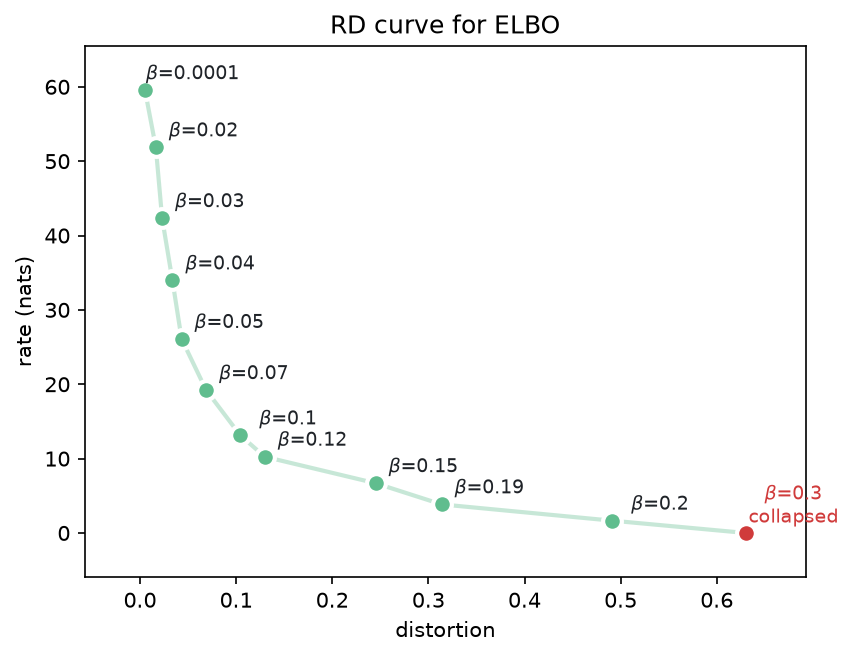

In [623]:
ACCENT, INK, MUTED = "#60BD8E", "#1f2328", "#8b9199"
COLLAPSE = "#d03b3b"
COLLAPSE_RATE = 1e-2   # nats; below this the latent carries no information

beta_to_remove = [0.01]
rd_points_elbo = [item for item in rd_points_elbo if item["beta"] not in beta_to_remove]

# pts = sorted(rd_points_elbo, key=lambda p: p["beta"])
pts = sorted(rd_points_elbo, key=lambda p: p["beta"])


D = [p["distortion"] for p in pts]
R = [p["rate"] for p in pts]
B = [p["beta"] for p in pts]
collapsed = [p["rate"] < COLLAPSE_RATE for p in pts]

# Pareto frontier: no other point has both lower rate and lower distortion.
# Collapsed runs aren't operating points, so they're excluded from the frontier.
on_front = [
    (not c) and not any(
        q["rate"] <= p["rate"] and q["distortion"] <= p["distortion"] and q is not p
        for q in pts
    )
    for p, c in zip(pts, collapsed)
]

fig, ax = plt.subplots(figsize=(6.2, 4.6), dpi=150)

# sweep trajectory, in beta order
ax.plot(D, R, "-", color=ACCENT, lw=2, alpha=0.35, zorder=1)

for d, r, c, front in zip(D, R, collapsed, on_front):
    if c:                                    # posterior collapse
        ax.plot(d, r, "o", ms=9, color=COLLAPSE, mec="white", mew=2, zorder=5)
    elif front:                              # on the frontier
        ax.plot(d, r, "o", ms=9, color=ACCENT, mec="white", mew=2, zorder=3)
    else:                                    # dominated by another beta
        ax.plot(d, r, "o", ms=9, color="white", mec=ACCENT, mew=2, zorder=4)

for d, r, b, c, front in zip(D, R, B, collapsed, on_front):
    label = rf"$\beta$={b:g}" + ("\ncollapsed" if c else "")
    ax.annotate(label, (d, r), textcoords="offset points",
                xytext=(23, 5), ha="center", fontsize=9,
                color=COLLAPSE if c else (INK if front else MUTED))

# ax.set_xscale("log") 
ax.set(ylabel='rate (nats)', xlabel='distortion')

R_range = max(R) - min(R)
ax.set(ylim=(min(R)-R_range*0.1, max(R)+R_range*0.1))
D_range = max(D) - min(D)
ax.set(xlim=(min(D)-D_range*0.1, max(D)+D_range*0.1))

ax.set(title="RD curve for ELBO")


# save the betas that are collapsed
collapse_beta_elbo = [b for b, c in zip(B, collapsed) if c]
print('collapse betas (elbo):', collapse_beta_elbo)

## compare tht two

[Text(0.5, 1.0, 'RD curve comparison')]

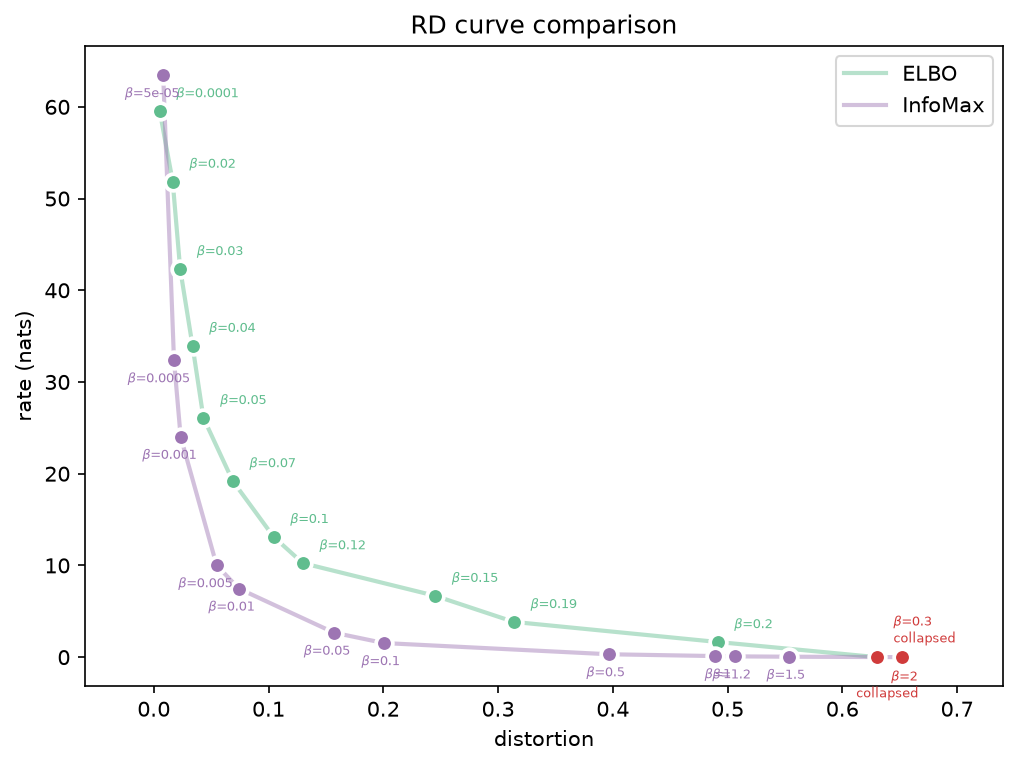

In [662]:
SERIES = [
    (rd_points_elbo, "ELBO",    "#60BD8E"),
    # (rd_points_kl, "ELBO",    "#2a78d6"),
    (rd_points,    "InfoMax", "#9D75B3"),
]

INK, MUTED, COLLAPSE = "#1f2328", "#8b9199", "#d03b3b"
COLLAPSE_RATE = 1e-2

fig, ax = plt.subplots(figsize=(7.0, 5.0), dpi=150)

for i, (points, label, color) in enumerate(SERIES):
    pts = sorted(points, key=lambda p: p["beta"])
    ax.plot(
        [p["distortion"] for p in pts],
        [p["rate"] for p in pts],
        "-", color=color, lw=2, alpha=0.45, zorder=1, label=label,
    )

    for p in pts:
        collapsed = p["rate"] < COLLAPSE_RATE
        point_color = COLLAPSE if collapsed else color

        ax.plot(
            p["distortion"], p["rate"], "o", ms=8,
            color=point_color, mec="white", mew=1.8,
            zorder=5 if collapsed else 3,
        )
        ax.annotate(
            rf"$\beta$={p['beta']:g}"
            + ("\ncollapsed" if collapsed else ""),
            (p["distortion"], p["rate"]),
            textcoords="offset points",
            xytext=(8, 5 if i == 0 else -6),
            ha="left" if i==0 else "right",
            va="bottom" if i == 0 else "top",
            fontsize=6,
            color=point_color,
            zorder=6,
        )

# ax.set_xscale("log")
ax.set(ylabel="rate (nats)", xlabel="distortion")
ax.legend()
plt.tight_layout()

ax.set(xlim=(-.06, 0.74))
# R_range = max(R) - min(R)
# ax.set(ylim=(min(R)-R_range*0.1, max(R)+R_range*0.1))
# D_range = max(D) - min(D)
# ax.set(xlim=(min(D)-D_range*0.1, max(D)+D_range*0.1))

ax.set(title="RD curve comparison")

# get latents across beta

In [663]:
from utils.config_search import ConfigQuery, find_models, use_dataset
from utils.config_diff import diff_configs, print_diff

search_criteria = ConfigQuery(
    rate_type = "norm",
    latent_dim = 2,
)

use_dataset("ellipse")
nums_norm = find_models(search_criteria)

if len(nums_norm) == 1:
    print(nums_norm)
else:
    print_diff(nums_norm)

print(len(nums_norm))

1 differing fields across models [14, 15, 16, 17, 18, 19, 20, 21, 23, 24, 25, 26]

field      v014  v015  v016  v017  v018  v019   v020   v021    v023   v024  v025  v026
---------  ----  ----  ----  ----  ----  -----  -----  ------  -----  ----  ----  ----
beta_init  1.0   0.5   0.1   0.05  0.01  0.005  0.001  0.0005  5e-05  2.0   1.5   1.2
12


In [664]:
from utils.config_search import ConfigQuery, find_models, use_dataset
from utils.config_diff import diff_configs, print_diff

search_criteria = ConfigQuery(
    rate_type = "kl",
    latent_dim = 2,
)

use_dataset("ellipse")
nums_elbo = find_models(search_criteria)

if len(nums_elbo) == 1:
    print(nums_elbo)
else:
    print_diff(nums_elbo)

print(len(nums_elbo))

1 differing fields across models [1, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13]

field      v001    v003  v004  v005  v006  v007  v008  v009  v010  v011  v012  v013
---------  ------  ----  ----  ----  ----  ----  ----  ----  ----  ----  ----  ----
beta_init  0.0001  0.02  0.03  0.04  0.05  0.07  0.1   0.12  0.15  0.19  0.2   0.3
12


In [665]:
n_input_samples = 500
dataset = EllipseDataset(n_samples=n_input_samples, noise=0.0)
data = dataset.data
factors = dataset.factors


# now put this data into the encoder and see what the latent means are
x = torch.as_tensor(data, dtype=torch.float32, device=next(model.infnet.parameters()).device)
f = torch.as_tensor(factors, dtype=torch.float32)

In [707]:
all_means_norm = []
all_means_elbo = []

# infomax
for i, model_num in enumerate(nums_norm):
    config, model, weights = init_sami_from_config(dataset_name="ellipse", model_num=model_num)
    assert config.rate_type == 'norm'
    model.load_state_dict(weights)
    model.eval()
    sami_inference = SAMI_Inference_MLP(sami=model, config=config).to(device)

    sami_inference.eval()
    with torch.no_grad():
        means, logvars = sami_inference.encode(model.infnet, x, t=None)
        samples = sami_inference.infnet.sample(means, logvars)
    all_means_norm.append({"beta": config.beta_init, "means": means, "samples": samples})

for i, model_num_kl in enumerate(nums_elbo):
    # elbo
    config, model, weights = init_sami_from_config(dataset_name="ellipse", model_num=model_num_kl)
    assert config.rate_type == 'kl'
    model.load_state_dict(weights)
    model.eval()
    sami_inference = SAMI_Inference_MLP(sami=model, config=config).to(device)

    sami_inference.eval()
    with torch.no_grad():
        means, logvars = sami_inference.encode(model.infnet, x, t=None)
        samples = sami_inference.infnet.sample(means, logvars)
    all_means_elbo.append({"beta": config.beta_init, "means": means, "samples": samples})

all_means_norm.sort(key=lambda d: d["beta"])
# all_means_norm = [d for d in all_means_norm if d['beta']!=1.0 and d['beta']!=0.5]

all_means_elbo.sort(key=lambda d: d["beta"])
# all_means_elbo = [d for d in all_means_kl if d['beta']!=1.0 and d['beta']!=0.5]

In [708]:
rd_points_norm_no_collapse = [d for d in rd_points if d['beta'] not in collapse_betas]
rd_points_elbo_no_collapse = [d for d in rd_points_elbo if d['beta'] not in collapse_beta_elbo]

all_means_norm_no_collapse = [d for d in all_means_norm if d['beta'] not in collapse_betas]
all_means_elbo_no_collapse = [d for d in all_means_elbo if d['beta'] not in collapse_beta_elbo]

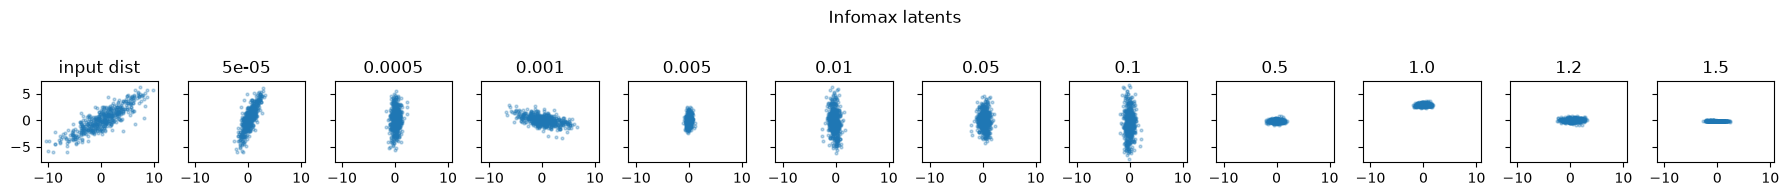

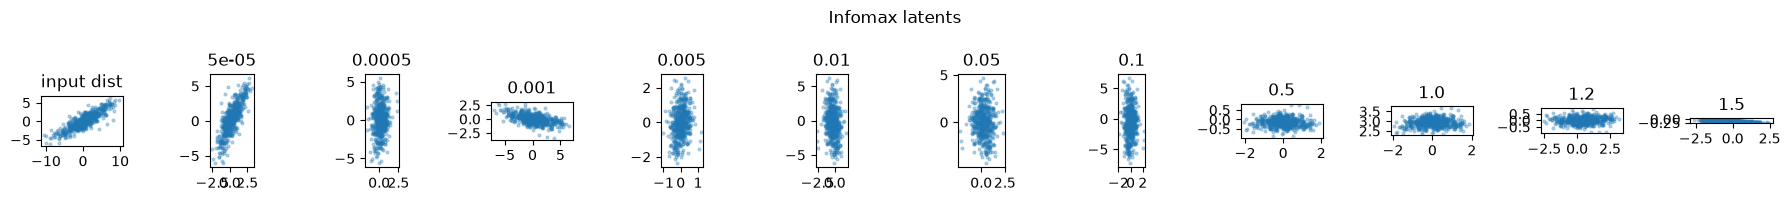

In [710]:
fig, ax = plt.subplots(1, len(all_means_norm_no_collapse)+1, figsize=(18, 2), sharex=True, sharey=True)

# show the latents across betas
ax[0].scatter(*data.T, s=4, alpha=0.3)
ax[0].set(title='input dist')
ax[0].set_aspect("equal")


for i in range(len(all_means_norm_no_collapse)):
    ax[i+1].scatter(*all_means_norm_no_collapse[i]["means"].T, s=4, alpha=0.3)
    ax[i+1].set_aspect("equal")
    ax[i+1].set(title=all_means_norm_no_collapse[i]["beta"])

fig.suptitle("Infomax latents")
fig.tight_layout()


# show the latents across betas
fig, ax = plt.subplots(1, len(all_means_norm_no_collapse)+1, figsize=(18, 2))

ax[0].scatter(*data.T, s=4, alpha=0.3)
ax[0].set(title='input dist')
ax[0].set_aspect("equal")

for i in range(len(all_means_norm_no_collapse)):
    ax[i+1].scatter(*all_means_norm_no_collapse[i]["means"].T, s=4, alpha=0.3)
    ax[i+1].set_aspect("equal")
    ax[i+1].set(title=all_means_norm_no_collapse[i]["beta"])

fig.suptitle("Infomax latents")
fig.tight_layout()

# samples rather than means
# fig, ax = plt.subplots(1, len(all_means_norm_no_collapse)+1, figsize=(18,2))

# ax[0].scatter(*data.T, s=4, alpha=0.3)
# ax[0].set(title='input dist')
# ax[0].set_aspect("equal")

# for i in range(len(all_means_norm_no_collapse)):
#     ax[i+1].scatter(*all_means_norm_no_collapse[i]["samples"].T, s=4, alpha=0.3)
#     ax[i+1].set_aspect("equal")
#     ax[i+1].set(title=all_means_norm_no_collapse[i]["beta"])


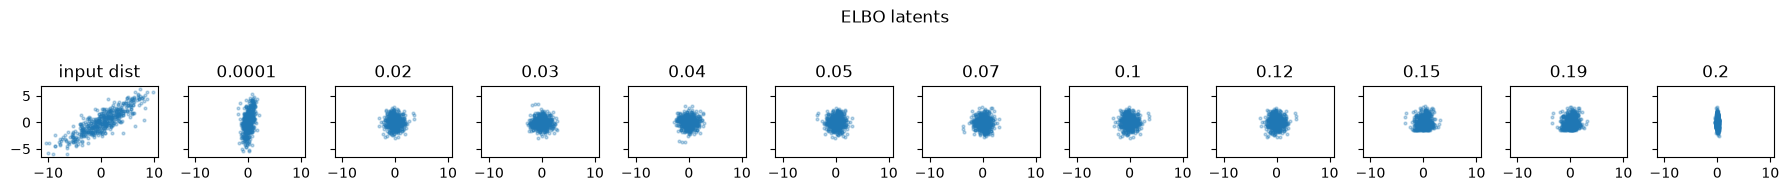

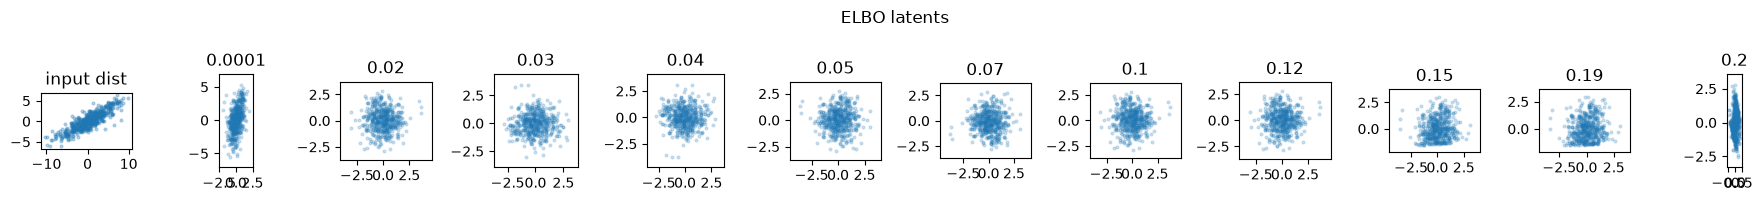

In [669]:
# show the latents across betas
fig, ax = plt.subplots(1, len(all_means_elbo_no_collapse)+1, figsize=(18, 2), sharex=True, sharey=True)

ax[0].scatter(*data.T, s=4, alpha=0.3)
ax[0].set(title='input dist')
ax[0].set_aspect("equal")

for i in range(len(all_means_elbo_no_collapse)):
    means = all_means_elbo_no_collapse[i]["means"]
    ax[i+1].scatter(*means.T, s=4, alpha=0.3)
    ax[i+1].set_aspect("equal")
    ax[i+1].set(title=all_means_elbo_no_collapse[i]["beta"])

fig.suptitle("ELBO latents")
fig.tight_layout()



# show the latents across betas
fig, ax = plt.subplots(1, len(all_means_elbo_no_collapse)+1, figsize=(18, 2))

ax[0].scatter(*data.T, s=4, alpha=0.3)
ax[0].set(title='input dist')
ax[0].set_aspect("equal")

for i in range(len(all_means_elbo_no_collapse)):
    means = all_means_elbo_no_collapse[i]["means"]
    ax[i+1].scatter(*means.T, s=4, alpha=0.2)

    # print(means.shape)
    xmin, ymin = means[:,0].min(), means[:,1].min()
    xmax, ymax = means[:,0].max(), means[:,1].max()
    xrange = xmax - xmin
    yrange = ymax - ymin
    
    ax[i+1].set(xlim=(xmin - xrange*0.15, xmax + xrange*0.15))
    ax[i+1].set(ylim=(ymin - yrange*0.15, ymax + yrange*0.15))
    ax[i+1].set_aspect("equal")
    ax[i+1].set(title=all_means_elbo_no_collapse[i]["beta"])

fig.suptitle("ELBO latents")
fig.tight_layout()

# measure the disentanglement

I want to make a 2x2 correlation matrix between the means and the true generative factors

## infomax

In [677]:
from scipy.stats import spearmanr
print(factors.shape)

corr_across_betas_norm = []  # pearson
sp_across_betas = []  # spearman 
print(len(all_means_norm_no_collapse))
for i in range(len(all_means_norm_no_collapse)):
    means = all_means_norm_no_collapse[i]["means"]
    beta = all_means_norm_no_collapse[i]["beta"]

    C = np.corrcoef(factors.T, means.T)[:2, 2:]   # slice the cross block
    A = np.abs(C)
    max_Cs = np.max(A, axis=1)
    corr_across_betas_norm.append({
        "beta": beta,
        "correlation": C,
        "max_corrs": max_Cs
    })

    rho = spearmanr(factors, means.numpy()).statistic[:2, 2:]
    A = np.abs(rho)
    max_rhos = np.max(A, axis=1)
    sp_across_betas.append({
        "beta": beta,
        "rho": rho,
        "max_rhos": max_rhos
    })

(500, 2)
11


11


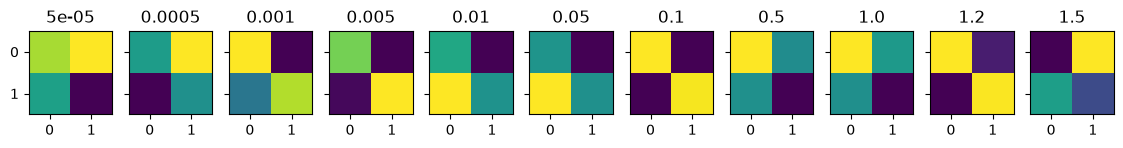

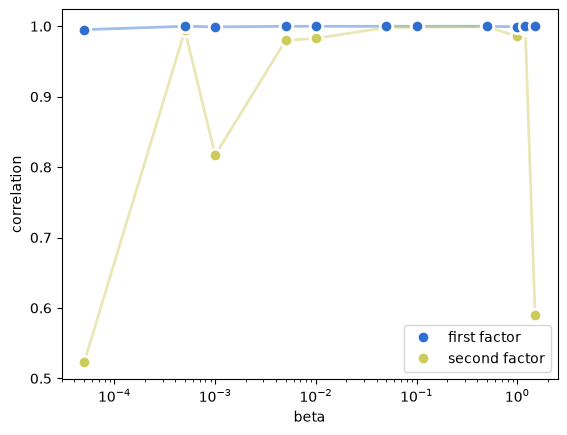

In [688]:
corrs_norm = sorted(corr_across_betas_norm, key=lambda c: c["beta"])

fig, ax = plt.subplots(1, len(corrs_norm), figsize=(14,2), sharey=True)
for i in range(len(corrs_norm)):
    ax[i].imshow(corrs_norm[i]['correlation'])
    ax[i].set(title=corrs_norm[i]['beta'])

print(len(corrs_norm))

B = [p["beta"] for p in corrs_norm]
C1 = [p["max_corrs"][0] for p in corrs_norm]
C2 = [p["max_corrs"][1] for p in corrs_norm]

FIRST, SECOND = "#2f6fd0", "#CDCB5B"
COLLAPSE = "#d03b3b"

fig, ax = plt.subplots(1, 1)
ax.plot(B, C1, "-", color=FIRST, lw=2, alpha=0.45)
ax.plot(B, C1, "o", color=FIRST, ms=9, mec="white", mew=2, zorder=5, label="first factor")
ax.plot(B, C2, "-", color=SECOND, lw=2, alpha=0.45)
ax.plot(B, C2, "o", color=SECOND, ms=9, mec="white", mew=2, zorder=4, label="second factor")

ax.set_xscale("log") 
ax.set(ylabel="correlation")
ax.set(xlabel="beta")
ax.legend()


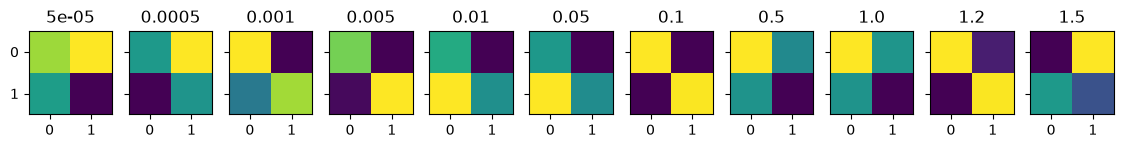

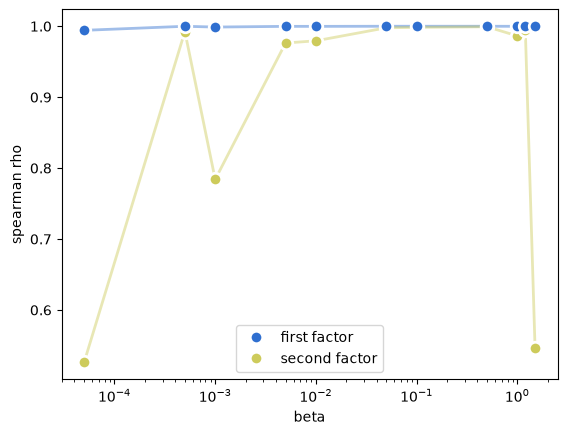

In [680]:
sps_norm = sorted(sp_across_betas, key=lambda c: c["beta"])

fig, ax = plt.subplots(1, len(sps_norm), figsize=(14,2), sharey=True)
for i in range(len(sps_norm)):
    ax[i].imshow(sps_norm[i]['rho'])
    ax[i].set(title=sps_norm[i]['beta'])

B = [p["beta"] for p in sps_norm]
C1_sp = [p["max_rhos"][0] for p in sps_norm]
C2_sp = [p["max_rhos"][1] for p in sps_norm]

FIRST, SECOND = "#2f6fd0", "#CDCB5B"
COLLAPSE = "#d03b3b"

fig, ax = plt.subplots(1, 1)
ax.plot(B, C1_sp, "-", color=FIRST, lw=2, alpha=0.45)
ax.plot(B, C1_sp, "o", color=FIRST, ms=9, mec="white", mew=2, zorder=5, label="first factor")
ax.plot(B, C2_sp, "-", color=SECOND, lw=2, alpha=0.45)
ax.plot(B, C2_sp, "o", color=SECOND, ms=9, mec="white", mew=2, zorder=4, label="second factor")

ax.set_xscale("log") 
ax.set(ylabel="spearman rho")
ax.set(xlabel="beta")
ax.legend()


## elbo

In [689]:
from scipy.stats import spearmanr
print(factors.shape)

corr_across_betas_elbo = []  # pearson
sp_across_betas_elbo = []  # spearman 
for i in range(len(all_means_elbo_no_collapse)):
    means = all_means_elbo_no_collapse[i]["means"]
    beta = all_means_elbo_no_collapse[i]["beta"]

    C = np.corrcoef(factors.T, means.T)[:2, 2:]   # slice the cross block
    A = np.abs(C)
    max_Cs = np.max(A, axis=1)
    corr_across_betas_elbo.append({
        "beta": beta,
        "correlation": C,
        "max_corrs": max_Cs
    })

    rho = spearmanr(factors, means.numpy()).statistic[:2, 2:]
    A = np.abs(rho)
    max_rhos = np.max(A, axis=1)
    sp_across_betas_elbo.append({
        "beta": beta,
        "rho": rho,
        "max_rhos": max_rhos
    })


(500, 2)


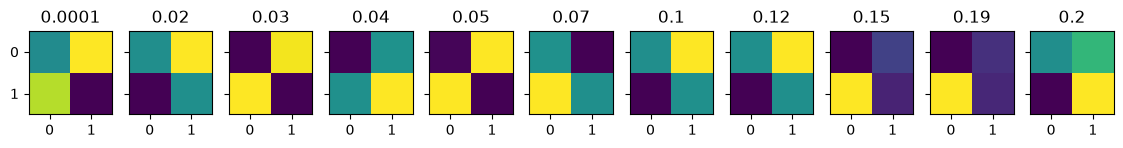

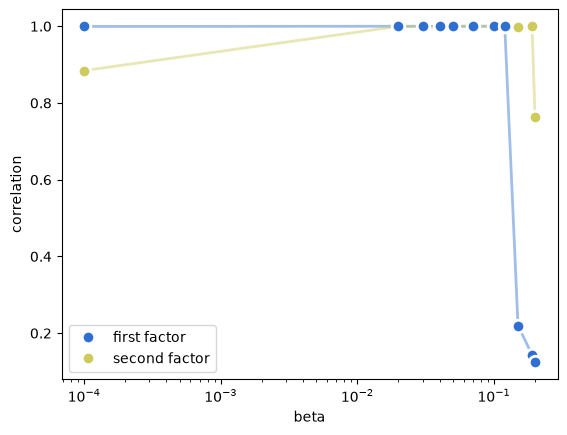

In [682]:
corrs_elbo = sorted(corr_across_betas_elbo, key=lambda c: c["beta"])

fig, ax = plt.subplots(1, len(corrs_elbo), figsize=(14,2), sharey=True)
for i in range(len(corrs_elbo)):
    ax[i].imshow(corrs_elbo[i]['correlation'])
    ax[i].set(title=corrs_elbo[i]['beta'])

B_elbo = [p["beta"] for p in corrs_elbo]
C1_elbo = [p["max_corrs"][0] for p in corrs_elbo]
C2_elbo = [p["max_corrs"][1] for p in corrs_elbo]

FIRST, SECOND = "#2f6fd0", "#CDCB5B"
COLLAPSE = "#d03b3b"

fig, ax = plt.subplots(1, 1)
ax.plot(B_elbo, C1_elbo, "-", color=FIRST, lw=2, alpha=0.45)
ax.plot(B_elbo, C1_elbo, "o", color=FIRST, ms=9, mec="white", mew=2, zorder=5, label="first factor")
ax.plot(B_elbo, C2_elbo, "-", color=SECOND, lw=2, alpha=0.45)
ax.plot(B_elbo, C2_elbo, "o", color=SECOND, ms=9, mec="white", mew=2, zorder=4, label="second factor")

ax.set_xscale("log") 
ax.set(ylabel="correlation")
ax.set(xlabel="beta")
ax.legend()


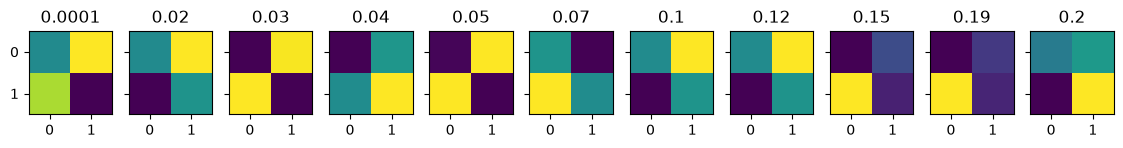

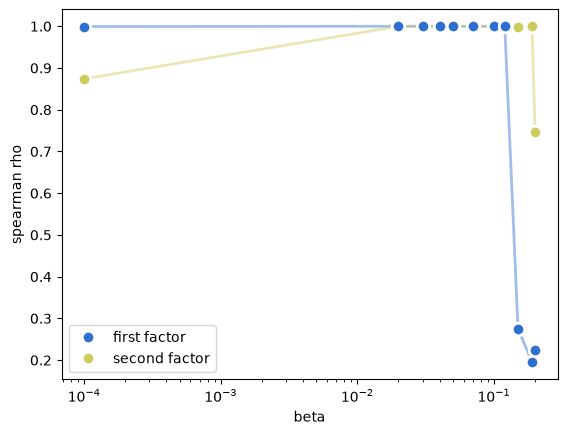

In [690]:
sps_elbo = sorted(sp_across_betas_elbo, key=lambda c: c["beta"])

fig, ax = plt.subplots(1, len(sps_elbo), figsize=(14,2), sharey=True)
for i in range(len(sps_elbo)):
    ax[i].imshow(sps_elbo[i]['rho'])
    ax[i].set(title=sps_elbo[i]['beta'])

# B_elbo = [p["beta"] for p in sps_elbo]
C1_elbo_sp = [p["max_rhos"][0] for p in sps_elbo]
C2_elbo_sp = [p["max_rhos"][1] for p in sps_elbo]

FIRST, SECOND = "#2f6fd0", "#CDCB5B"
COLLAPSE = "#d03b3b"

fig, ax = plt.subplots(1, 1)
ax.plot(B_elbo, C1_elbo_sp, "-", color=FIRST, lw=2, alpha=0.45)
ax.plot(B_elbo, C1_elbo_sp, "o", color=FIRST, ms=9, mec="white", mew=2, zorder=5, label="first factor")
ax.plot(B_elbo, C2_elbo_sp, "-", color=SECOND, lw=2, alpha=0.45)
ax.plot(B_elbo, C2_elbo_sp, "o", color=SECOND, ms=9, mec="white", mew=2, zorder=4, label="second factor")

ax.set_xscale("log") 
ax.set(ylabel="spearman rho")
ax.set(xlabel="beta")
ax.legend()


## comparison

[Text(0.5, 1.0, 'correlation as a fn of beta')]

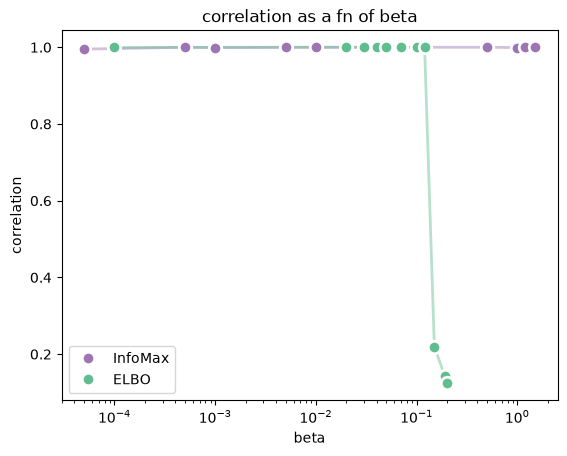

In [696]:
INFOMAX, ELBO = "#9D75B3", "#60BD8E"

fig, ax = plt.subplots(1, 1)
ax.plot(B, C1, "-", color=INFOMAX, lw=2, alpha=0.45)
ax.plot(B, C1, "o", color=INFOMAX, ms=9, mec="white", mew=2, zorder=5, label="InfoMax")
ax.plot(B_elbo, C1_elbo, "-", color=ELBO, lw=2, alpha=0.45)
ax.plot(B_elbo, C1_elbo, "o", color=ELBO, ms=9, mec="white", mew=2, zorder=5, label="ELBO")
# ax.plot(B_elbo, C2_elbo, "-", color=SECOND, lw=2, alpha=0.45)
# ax.plot(B_elbo, C2_elbo, "o", color=SECOND, ms=9, mec="white", mew=2, zorder=4, label="second factor")

ax.set_xscale("log") 
ax.set(ylabel="correlation")
ax.set(xlabel="beta")
ax.legend()
ax.set(title='correlation as a fn of beta')

In [702]:
# as a function of distortion and of rate

rd_points_norm_no_collapse = sorted(rd_points_norm_no_collapse, key=lambda p: p["beta"])
D = [p["distortion"] for p in rd_points_norm_no_collapse]
R = [p['rate'] for p in rd_points_norm_no_collapse]


B = [p["beta"] for p in corrs_norm]
C1 = [p["max_corrs"][0] for p in corrs_norm]
C2 = [p["max_corrs"][1] for p in corrs_norm]

rd_points_elbo_no_collapse = sorted(rd_points_elbo_no_collapse, key=lambda p: p["beta"])
D_elbo = [p["distortion"] for p in rd_points_elbo_no_collapse]
R_elbo = [p["rate"] for p in rd_points_elbo_no_collapse]
# B_elbo = [p["beta"] for p in rd_pts_elbo]

# pts = sorted(corr_across_betas_elbo, key=lambda c: c["beta"])
B_elbo = [p["beta"] for p in corrs_elbo]
C1_elbo = [p["max_corrs"][0] for p in corrs_elbo]
C2_elbo = [p["max_corrs"][1] for p in corrs_elbo]

[Text(0.5, 1.0, 'correlation as a fn of distortion')]

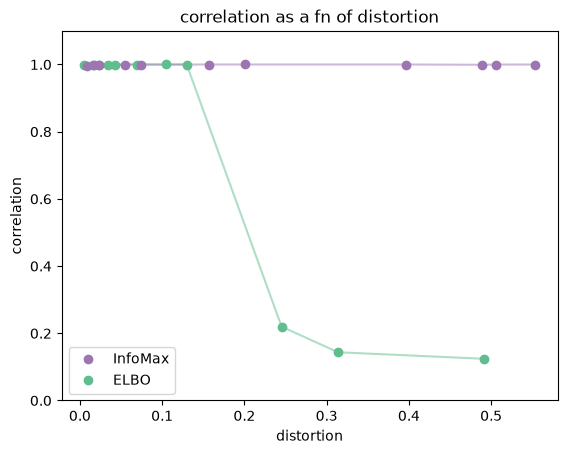

In [703]:
fig, ax = plt.subplots(1, 1)

INFOMAX, ELBO = "#9D75B3", "#60BD8E"
ax.plot(D, C1, '-', color=INFOMAX, alpha=0.5, zorder=2)
ax.plot(D, C1, 'o', color=INFOMAX, zorder=5, label="InfoMax",)
ax.plot(D_elbo, C1_elbo, '-', color=ELBO, alpha=0.5, zorder=1)
ax.plot(D_elbo, C1_elbo, 'o', color=ELBO, zorder=4, label="ELBO",)
ax.set(xlabel='distortion', ylabel='correlation')
ax.legend()

ax.set_ylim([0, 1.1])
ax.set(title='correlation as a fn of distortion')

[Text(0.5, 1.0, 'correlation as a fn of rate')]

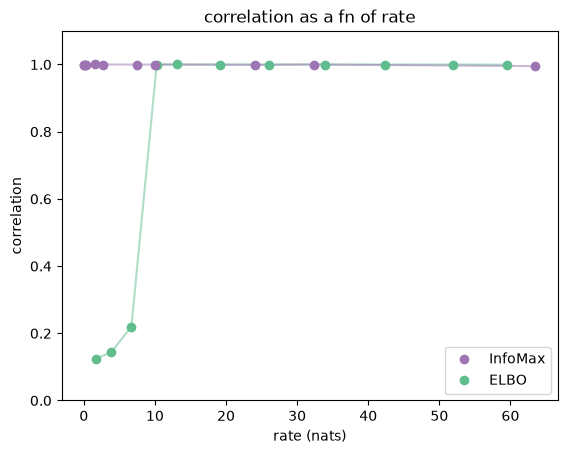

In [705]:
fig, ax = plt.subplots(1, 1)
# print(len(D), len(C1))
# INFOMAX, ELBO = "#DBA607", "#63A383"
INFOMAX, ELBO = "#9D75B3", "#60BD8E"
ax.plot(R, C1, '-', color=INFOMAX, alpha=0.5,  zorder=2)
ax.plot(R, C1, 'o', color=INFOMAX, zorder=5, label="InfoMax",)
# print(len(D_kl), len(C1_kl))
ax.plot(R_elbo, C1_elbo, '-', color=ELBO, alpha=0.5, zorder=1)
ax.plot(R_elbo, C1_elbo, 'o', color=ELBO, zorder=4, label="ELBO")
ax.set(xlabel='rate (nats)', ylabel='correlation')
ax.legend()

ax.set_ylim([0, 1.1])
ax.set(title='correlation as a fn of rate')

# measure information across scales

measure how much the code contains knowledge about each factor over the course of denoising



In [741]:
from utils.config_search import ConfigQuery, find_models, use_dataset
from utils.config_diff import diff_configs, print_diff

search_criteria = ConfigQuery(
    rate_type = "norm",
    latent_dim = 2,
)

use_dataset("ellipse")
nums_norm = find_models(search_criteria)

if len(nums_norm) == 1:
    print(nums_norm)
else:
    print_diff(nums_norm)

print(len(nums_norm))

1 differing fields across models [14, 15, 16, 17, 18, 19, 20, 21, 23, 24, 25, 26]

field      v014  v015  v016  v017  v018  v019   v020   v021    v023   v024  v025  v026
---------  ----  ----  ----  ----  ----  -----  -----  ------  -----  ----  ----  ----
beta_init  1.0   0.5   0.1   0.05  0.01  0.005  0.001  0.0005  5e-05  2.0   1.5   1.2
12


In [742]:
from d_analysis.utils.sami_simple import init_sami_from_config
from b_models.sami.sami_inference_mlp import SAMI_Inference_MLP

dataset_name = "ellipse"  # ring or ellipse
model_num = 15

config, model, weights = init_sami_from_config(dataset_name, model_num)
model.load_state_dict(weights)
model.eval()
sami_inference = SAMI_Inference_MLP(sami=model, config=config).to(device)

print('beta value:', f'{config.beta_init:.2e}')
print('rate type:', f'{config.rate_type}')

beta value: 5.00e-01
rate type: norm


number of samples: 100


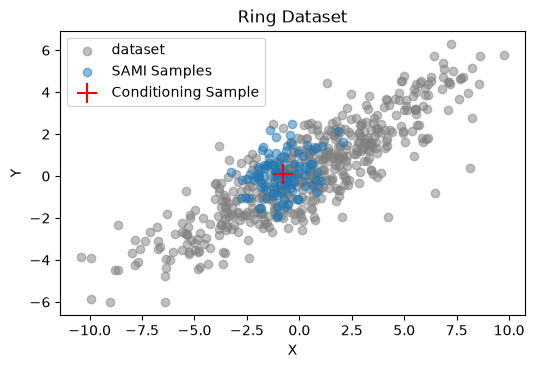

In [748]:
sami_inference.eval()

conditioning_sample = torch.tensor([[-0.8, 0.1]]).to(device)

sami_inference.conditional_sample(
    N = 100,
    target_x_input = conditioning_sample,
)

samples = sami_inference.x0_estimates[0].cpu().numpy()
print('number of samples:', samples.shape[0])
conditioning_sample_np = conditioning_sample.cpu().numpy()

#plot
fig, ax = plt.subplots(figsize=(6, 6))

ax.scatter(data[:, 0], data[:, 1], alpha=0.5, label="dataset", color='gray')
ax.scatter(samples[:, 0], samples[:, 1], alpha=0.5, label="SAMI Samples")
ax.scatter(conditioning_sample_np[:, 0], conditioning_sample_np[:, 1], marker="+", alpha=1., s=200, color='red', label="Conditioning Sample")

ax.set(title="Ring Dataset", xlabel="X", ylabel="Y")
ax.set_aspect("equal")
# ax.set(xlim=(-1.5, 1.5), ylim=(-1.5, 1.5))
ax.legend(loc="upper left")

# samples

In [749]:
prior_score_norms = sami_inference.prior_score_magnitudes.square()
guidance_score_norms = sami_inference.guidance_score_magnitudes.square()
posterior_score_norms = sami_inference.posterior_score_magnitudes.square()
gammas = sami_inference.gammas

torch.Size([100])


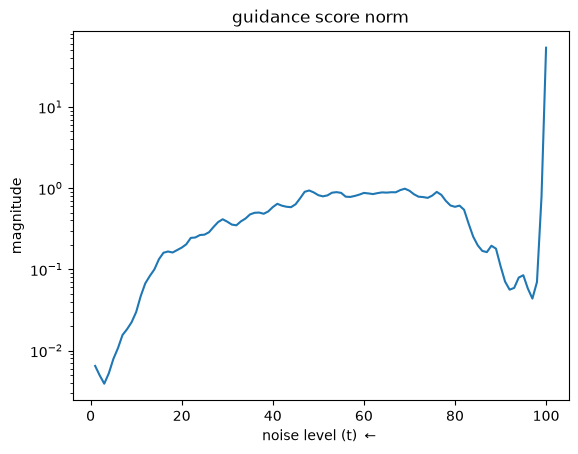

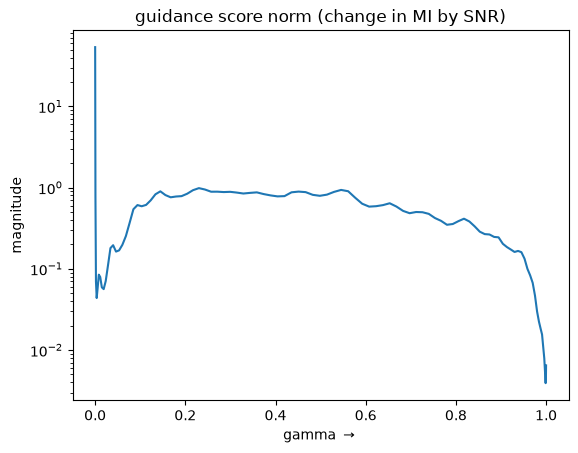

In [756]:
print(guidance_score_norms.shape)

# def plot_norms(score_norms, title=""):
fig, ax = plt.subplots(1, 1)
xaxis = np.arange(len(guidance_score_norms), 0, -1)
ax.plot(xaxis, guidance_score_norms)
ax.set(xlabel="noise level (t) $\\leftarrow$")
ax.set(ylabel="magnitude")
ax.set_title(f"guidance score norm")
ax.set_yscale("log")

fig, ax = plt.subplots(1, 1)
ax.plot(gammas, guidance_score_norms)
ax.set(xlabel="gamma $\\rightarrow$")
ax.set(ylabel="magnitude")
ax.set_title(f"guidance score norm (change in MI by SNR)")
ax.set_yscale("log")



# plot_norms(prior_score_norm, "prior score norm")
# plot_norms(guidance_score_norm, "guidance score norm")
# plot_norms(posterior_score_norm, "posterior score norm")

In [ ]:
# now get the guidance score with respect to a single latent rather than the whole latent
guidance_scores = sami_inference.guidance_score  # shape (n_timesteps, latent_dims)


guidance_scores

torch.mean(torch.norm(self.posterior_score, dim=1))

In [760]:
print(guidance_scores.shape)

torch.Size([100, 2])
